# 01 Linguistic Library Construction

Build WHS and NLP language libraries.

•	Collect WHS-specific terminology from ELRC Share and Safe Work Australia sources.
•	Extract NLP linguistic constructs from INLPTA resources and the Milton/Meta model.
•	Build two dictionaries: WHS_Terms and NLP_Language_Patterns.
•	Preprocess terms (e.g., lowercasing, token cleaning, lemmatization).
•	Export into formats for use in TF-IDF and rule-based validation (CSV, Excel).
•	Test term detection against a small sample of incident descriptions.

A.Setup
B. define NLP meta model terms
C. Define WHS Terms from glossary www.safeworkaustralia.com.au


In [6]:
#1` Set up and import libraries
import pandas as pd
import re
import os


In [7]:
#2 Define Milton Model NLP language patterns exctracted from https://nlpsure.com/nlp-milton-model-language-patterns/ by ChatGPT

milton_patterns = [
    {
        "Pattern": "Mind Reading",
        "Description": "Assuming someone else's thoughts or feelings without evidence.",
        "Example": "I know what you're thinking.",
        "Regex Hint": r"\bI know (what|how)\b"
    },
    {
        "Pattern": "Lost Performative",
        "Description": "Value judgment without stating who is making the judgment.",
        "Example": "That's bad.",
        "Regex Hint": r"\b(that|this|it)('s| is) (good|bad|important|wrong)\b"
    },
    {
        "Pattern": "Cause and Effect",
        "Description": "Implying one event causes another without clear link.",
        "Example": "You're making me upset.",
        "Regex Hint": r"\byou.*make(s|d)? me\b"
    },
    {
        "Pattern": "Complex Equivalence",
        "Description": "Assuming two unrelated things are equal.",
        "Example": "He's not smiling, so he must be angry.",
        "Regex Hint": r"\bso (he|she|they|I) (must|has to|is)\b"
    },
    {
        "Pattern": "Presupposition",
        "Description": "Assuming something is true within the structure of the sentence.",
        "Example": "Have you stopped ignoring the warnings?",
        "Regex Hint": r"\bstopped\b.*(ignoring|avoiding|denying)"
    },
    {
        "Pattern": "Universal Quantifiers",
        "Description": "Using extreme, generalized language.",
        "Example": "Everyone always does this.",
        "Regex Hint": r"\b(always|never|everyone|no one)\b"
    },
    {
        "Pattern": "Modal Operators",
        "Description": "Words that imply necessity, possibility or impossibility.",
        "Example": "You must comply.",
        "Regex Hint": r"\bmust|should|have to|can't|need to\b"
    },
    {
        "Pattern": "Nominalization",
        "Description": "Turning a process into a static noun.",
        "Example": "There’s no communication.",
        "Regex Hint": r"\b(communication|failure|management|control)\b"
    },
    {
        "Pattern": "Unspecified Verb",
        "Description": "Using vague or abstract verbs.",
        "Example": "They handled it.",
        "Regex Hint": r"\bhandled|addressed|dealt with|resolved\b"
    },
    {
        "Pattern": "Unspecified Referential Index",
        "Description": "No clear subject for the statement.",
        "Example": "They said it was fine.",
        "Regex Hint": r"\bthey said\b|\bpeople (say|told)\b"
    }
]

df_milton = pd.DataFrame(milton_patterns)
# Show all rows from the Milton Model patterns DataFrame
df_milton_patterns



,Pattern,Description,Example,Regex Hint
0,Mind Reading,Assuming someone else's thoughts or feelings w...,I know what you're thinking.,\bI know (what|how)\b
1,Lost Performative,Value judgment without stating who is making t...,That's bad.,\b(that|this|it)('s| is) (good|bad|important|w...
2,Cause and Effect,Implying one event causes another without clea...,You're making me upset.,\byou.*make(s|d)? me\b
3,Complex Equivalence,Assuming two unrelated things are equal.,"He's not smiling, so he must be angry.",\bso (he|she|they|I) (must|has to|is)\b
4,Presupposition,Assuming something is true within the structur...,Have you stopped ignoring the warnings?,\bstopped\b.*(ignoring|avoiding|denying)


In [41]:
# Show all rows from the Milton Model patterns DataFrame
df_milton

,Milton Pattern,Frequency
0,can,44
1,should,42
2,must,33
3,will,31
4,some,14
5,need,12
6,change,10
7,consider,10
8,someone,6
9,understand,5


In [8]:
#3 Export paterns to csv
df_milton.to_csv("milton_model_patterns.csv", index=False)
print("Exported to milton_model_patterns.csv")

Exported to milton_model_patterns.csv


## B. WHS terms 
https://www.safeworkaustralia.gov.au/glossary

In [32]:
#!pip install python-docx
!pip install wordcloud


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\krist\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\krist\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\krist\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


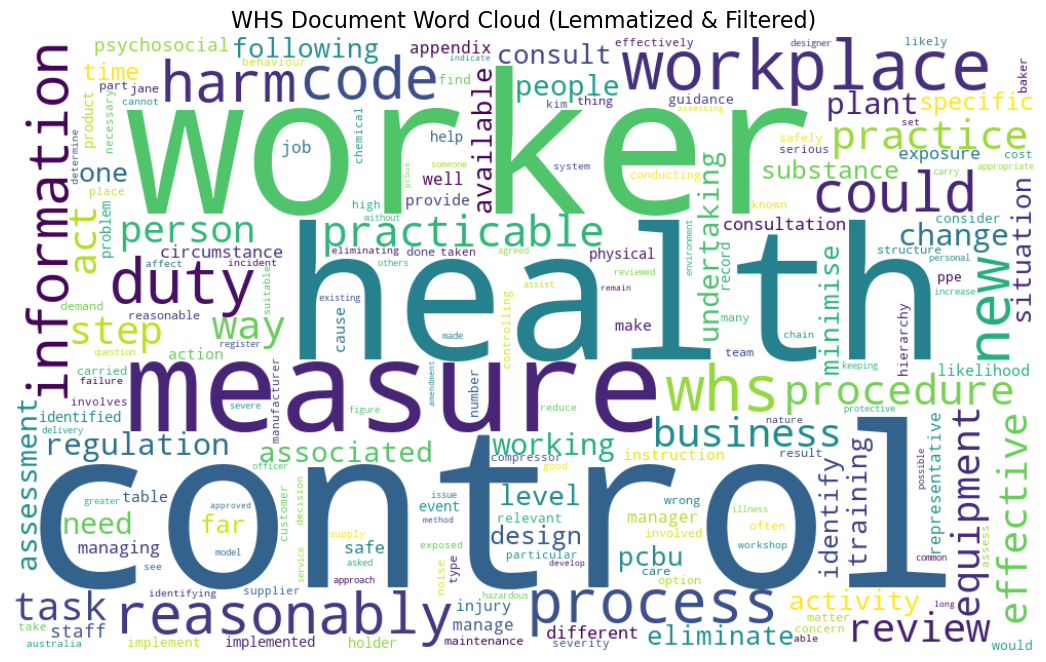

In [36]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords, wordnet
from collections import Counter
from docx import Document
import pandas as pd
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Set up stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
custom_stopwords = stop_words.union({
    'risk', 'risks', 'hazard', 'hazards', 'work', 'works', 'safety', 'management',
    'section', 'sections', 'subsection', 'page', 'pages', 'use', 'uses', 'used', 'using',
    'occur', 'occurs', 'occurred', 'occurring', 'example', 'examples',
    'includes', 'including', 'include',
    'must', 'may', 'also', 'among', 'amongst', 'another', 'based',
    'first', 'second', 'third', 'within', 'across', 'ensure', 'provided', 'provides',
    'require', 'required', 'requirements', 'requirement'
})
lemmatizer = WordNetLemmatizer()

# Load document
doc_path = "model_code_of_practice-how_to_manage_work_health_and_safety_risks-nov24.docx"
doc = Document(doc_path)
text = "\n".join([para.text for para in doc.paragraphs])

# Tokenize, lowercase, and lemmatize words
words = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())
lemmatized_words = [lemmatizer.lemmatize(word) for word in words if word not in custom_stopwords]

# Count word frequencies
word_counts = Counter(lemmatized_words)

# Create and show word cloud
wordcloud = WordCloud(width=1000, height=600, background_color='white').generate_from_frequencies(word_counts)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WHS Document Word Cloud (Lemmatized & Filtered)", fontsize=16)
plt.show()
